# Code-Capacity Trace Of Signed Memory Coefficients

This notebook isolates the memory update itself before Relay ensembling.

Experiment convention:
- choose one even-weight row from `Hx` to define an `X`-error support pattern
- flip exactly half of that row support
- compute the syndrome with `Hz`
- decode with `Hz`

The traced quantities are the native min-sum posterior ratios on the flipped bits across iterations.
Negative random memory coefficients are included because the goal is to see whether signed memory changes the trajectory enough to avoid the same basin that positive-only memory follows.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import relay_bp

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=140, suppress=True)

In [2]:
CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.01
max_iter = 40
alpha = 1.0
same_memory_coefficient = 0.15
random_positive_range = (0.0, 2.0)
random_signed_range = (-0.1, 1.9)
memory_application_scope = "all_bits"  # options: "stabilizer_support", "all_bits"
random_coefficient_seed_offsets = [0, 1, 2]
core_seed_zero = 0
core_seed_grid = list(range(1, 11))

DECODER_SPECS = {
    "bp": {
        "label": "Vanilla BP",
        "coeff_seed_offsets": [0],
    },
    "mem_same": {
        "label": "Mem-BP / same coefficient",
        "coeff_seed_offsets": [0],
    },
    "mem_positive_random": {
        "label": "Mem-BP / random positive coefficients",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
    "mem_signed_random": {
        "label": "Mem-BP / random signed coefficients",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
}

In [3]:
def load_css_code(path: Path) -> dict[str, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return {key: np.asarray(data[key], dtype=np.uint8) % 2 for key in ["Hx", "Hz", "Lx", "Lz"]}


def choose_even_weight_x_stabilizer(hx: np.ndarray, core_seed: int) -> tuple[int, list[int]]:
    row_weights = hx.sum(axis=1)
    eligible_rows = np.flatnonzero((row_weights > 0) & ((row_weights % 2) == 0))
    if eligible_rows.size == 0:
        raise ValueError("No even-weight row exists in Hx.")
    rng = np.random.default_rng(core_seed)
    row_idx = int(rng.choice(eligible_rows))
    support_bits = np.flatnonzero(hx[row_idx]).astype(int).tolist()
    return row_idx, support_bits


def build_half_stabilizer_x_error(problem_seed: int, hx: np.ndarray, hz: np.ndarray) -> dict[str, object]:
    row_idx, support_bits = choose_even_weight_x_stabilizer(hx, problem_seed)
    if len(support_bits) % 2 != 0:
        raise ValueError("Selected Hx row is not even weight.")
    rng = np.random.default_rng(problem_seed)
    #flipped_bits = [6,7]
    flipped_bits = sorted(rng.choice(np.asarray(support_bits, dtype=int), size=len(support_bits) // 2, replace=False).astype(int).tolist())
    error = np.zeros(hz.shape[1], dtype=np.uint8)
    error[flipped_bits] = 1
    syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
    return {
        "core_seed": problem_seed,
        "hx_row": row_idx,
        "support_bits": support_bits,
        "flipped_bits": flipped_bits,
        "error": error,
        "syndrome": syndrome,
        "row_weight": len(support_bits),
        "syndrome_weight": int(syndrome.sum()),
    }


def get_memory_target_indices(n_bits: int, support_bits: list[int]) -> np.ndarray:
    if memory_application_scope == "stabilizer_support":
        return np.asarray(support_bits, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(decoder_kind: str, n_bits: int, support_bits: list[int], coeff_seed: int) -> np.ndarray | None:
    if decoder_kind == "bp":
        return None

    target_indices = get_memory_target_indices(n_bits, support_bits)
    strengths = np.zeros(n_bits, dtype=np.float64)

    if decoder_kind == "mem_same":
        strengths[target_indices] = same_memory_coefficient
        return strengths

    rng = np.random.default_rng(coeff_seed)
    if decoder_kind == "mem_positive_random":
        strengths[target_indices] = rng.uniform(random_positive_range[0], random_positive_range[1], size=target_indices.size)
        return strengths

    if decoder_kind == "mem_signed_random":
        strengths[target_indices] = rng.uniform(random_signed_range[0], random_signed_range[1], size=target_indices.size)
        return strengths

    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def make_tracer(decoder_kind: str, check_matrix, error_priors: np.ndarray):
    gamma0 = None if decoder_kind == "bp" else 0.0
    return relay_bp.MinSumBPDecoderTraceF64(
        check_matrix,
        error_priors=error_priors,
        max_iter=max_iter,
        alpha=alpha,
        gamma0=gamma0,
    )


def run_single_trace(problem: dict[str, object], decoder_kind: str, coeff_seed_offset: int, check_matrix) -> dict[str, object]:
    coeff_seed = int(problem["core_seed"]) + coeff_seed_offset
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(decoder_kind, check_matrix, error_priors)
    tracer.reset()

    memory_strengths = build_memory_strengths(decoder_kind, check_matrix.shape[1], problem["support_bits"], coeff_seed)
    if memory_strengths is not None:
        tracer.set_memory_strengths(memory_strengths)

    snapshots = [tracer.snapshot(problem["syndrome"]) ]
    while tracer.current_iteration < max_iter and not snapshots[-1].success:
        snapshots.append(tracer.run_iteration(problem["syndrome"]))

    posterior_trace = np.vstack([np.asarray(snapshot.posterior_ratios, dtype=np.float64) for snapshot in snapshots])
    return {
        "decoder_kind": decoder_kind,
        "coeff_seed": coeff_seed,
        "coeff_seed_offset": coeff_seed_offset,
        "memory_strengths": memory_strengths,
        "snapshots": snapshots,
        "iterations": [int(snapshot.iterations) for snapshot in snapshots],
        "posterior_trace": posterior_trace,
        "final_decoding": np.asarray(snapshots[-1].decoding, dtype=np.uint8),
        "final_decoded_detectors": np.asarray(snapshots[-1].decoded_detectors, dtype=np.uint8),
        "success": bool(snapshots[-1].success),
        "final_iterations": int(snapshots[-1].iterations),
    }


def run_decoder_experiment(core_seed: int, decoder_kind: str, code_data: dict[str, np.ndarray], check_matrix) -> dict[str, object]:
    problem = build_half_stabilizer_x_error(core_seed, code_data["Hx"], code_data["Hz"])
    runs = [
        run_single_trace(problem, decoder_kind, coeff_seed_offset, check_matrix)
        for coeff_seed_offset in DECODER_SPECS[decoder_kind]["coeff_seed_offsets"]
    ]
    return {
        "problem": problem,
        "decoder_kind": decoder_kind,
        "decoder_label": DECODER_SPECS[decoder_kind]["label"],
        "runs": runs,
    }


def experiment_overview_table(experiment: dict[str, object]) -> pd.DataFrame:
    problem = experiment["problem"]
    return pd.DataFrame([
        {
            "decoder": experiment["decoder_label"],
            "core_seed": problem["core_seed"],
            "hx_row": problem["hx_row"],
            "row_weight": problem["row_weight"],
            "support_bits": problem["support_bits"],
            "flipped_bits": problem["flipped_bits"],
            "syndrome_weight": problem["syndrome_weight"],
        }
    ])


def coefficient_table(experiment: dict[str, object]) -> pd.DataFrame:
    rows = []
    problem = experiment["problem"]
    traced_bits = problem["flipped_bits"]
    support_bits = tuple(int(bit) for bit in problem["support_bits"])
    support_bit_set = set(support_bits)
    for run in experiment["runs"]:
        strengths = run["memory_strengths"]
        final_estimated_error_bits = np.flatnonzero(run["final_decoding"]).astype(int).tolist()
        estimated_bits_in_support = [bit for bit in final_estimated_error_bits if bit in support_bit_set]
        estimated_bits_outside_support = [bit for bit in final_estimated_error_bits if bit not in support_bit_set]
        for bit in traced_bits:
            rows.append({
                "core_seed": problem["core_seed"],
                "decoder": experiment["decoder_label"],
                "coeff_seed": run["coeff_seed"],
                "coeff_seed_offset": run["coeff_seed_offset"],
                "bit": bit,
                "memory_coefficient": np.nan if strengths is None else float(strengths[bit]),
                "success": run["success"],
                "iterations": run["final_iterations"],
                "support_bits": list(support_bits),
                "final_estimated_error_bits": final_estimated_error_bits,
                "estimated_bits_in_support": estimated_bits_in_support,
                "estimated_bits_outside_support": estimated_bits_outside_support,
                "n_estimated_bits": len(final_estimated_error_bits),
                "n_estimated_bits_outside_support": len(estimated_bits_outside_support),
            })
    return pd.DataFrame(rows)


def plot_core_seed_experiment(experiment: dict[str, object]):
    problem = experiment["problem"]
    traced_bits = problem["flipped_bits"]
    #traced_bits = problem["support_bits"] 
    n_runs = len(experiment["runs"])
    fig, axes = plt.subplots(1, n_runs, figsize=(6.5 * n_runs, 4.5), squeeze=False)
    axes = axes.ravel()
    color_map = {bit: plt.cm.tab10(idx % 10) for idx, bit in enumerate(traced_bits)}
    line_styles = ["-", "--", "-.", ":"]

    for ax, run in zip(axes, experiment["runs"]):
        x_values = np.asarray(run["iterations"], dtype=int)
        for bit in traced_bits:
            ax.plot(
                x_values,
                run["posterior_trace"][:, bit],
                marker="o",
                linewidth=1.7,
                markersize=3.5,
                color=color_map[bit],
                linestyle=line_styles[run["coeff_seed_offset"] % len(line_styles)],
                label=f"bit {bit}",
            )
        ax.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
        ax.set_xlabel("iteration")
        ax.set_ylabel("posterior ratio")
        ax.set_title(
            f"coeff seed = core + {run['coeff_seed_offset']}\n"
            f"success = {run['success']} | iterations = {run['final_iterations']}",
            fontsize=10,
        )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(
        f"{experiment['decoder_label']} | code = {selected_code} | core seed = {problem['core_seed']}\n"
        f"Hx row = {problem['hx_row']} | support = {problem['support_bits']} | flipped / traced bits = {problem['flipped_bits']}",
        fontsize=12,
        y=1.03,
    )
    fig.tight_layout()
    return fig


def plot_seed_grid(decoder_kind: str, core_seeds: list[int], code_data: dict[str, np.ndarray], check_matrix):
    experiments = [run_decoder_experiment(core_seed, decoder_kind, code_data, check_matrix) for core_seed in core_seeds]
    fig, axes = plt.subplots(2, 5, figsize=(24, 10), squeeze=False)
    axes = axes.ravel()
    line_styles = ["-", "--", "-.", ":"]

    for ax, experiment in zip(axes, experiments):
        traced_bits = experiment["problem"]["flipped_bits"]
        #traced_bits = experiment["problem"]["support_bits"]
        color_map = {bit: plt.cm.tab10(idx % 10) for idx, bit in enumerate(traced_bits)}
        for run in experiment["runs"]:
            x_values = np.asarray(run["iterations"], dtype=int)
            for bit in traced_bits:
                label = f"b{bit}, +{run['coeff_seed_offset']}" if ax is axes[0] else None
                ax.plot(
                    x_values,
                    run["posterior_trace"][:, bit],
                    linewidth=1.2,
                    alpha=0.9,
                    color=color_map[bit],
                    linestyle=line_styles[run["coeff_seed_offset"] % len(line_styles)],
                    label=label,
                )
        ax.axhline(0.0, color="black", linewidth=0.6, linestyle=":")
        ax.set_title(
            f"core {experiment['problem']['core_seed']} | row {experiment['problem']['hx_row']}\n"
            f"flip {experiment['problem']['flipped_bits']} | ok = {experiment['runs'][-1]['success']}",
            fontsize=9,
        )
        ax.set_xlabel("iteration")
        ax.set_ylabel("posterior ratio")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", fontsize=8)
    fig.suptitle(
        f"{DECODER_SPECS[decoder_kind]['label']} | code = {selected_code} | core seeds = {core_seeds[0]}..{core_seeds[-1]}",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()
    coefficient_tables = pd.concat([coefficient_table(experiment) for experiment in experiments], ignore_index=True)
    return experiments, coefficient_tables, fig


code_data = load_css_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))

display(
    pd.DataFrame(
        [
            {
                "code": selected_code,
                "npz_path": str(npz_path),
                "Hx_shape": code_data["Hx"].shape,
                "Hz_shape": code_data["Hz"].shape,
                "Lx_shape": code_data["Lx"].shape,
                "Lz_shape": code_data["Lz"].shape,
                "prior_error_rate": prior_error_rate,
                "max_iter": max_iter,
                "same_memory_coefficient": same_memory_coefficient,
                "random_positive_range": random_positive_range,
                "random_signed_range": random_signed_range,
                "memory_application_scope": memory_application_scope,
            }
        ]
    )
)

,code,npz_path,Hx_shape,Hz_shape,Lx_shape,Lz_shape,prior_error_rate,max_iter,same_memory_coefficient,random_positive_range,random_signed_range,memory_application_scope
0,gross,C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz,"(72, 144)","(72, 144)","(12, 144)","(12, 144)",0.01,40,0.15,"(0.0, 2.0)","(-0.1, 1.9)",all_bits


## Core Seed = 0

Each of the next four cells runs one decoder family at `core_seed = 0`.
For the random-memory variants, the same `X`-error instance is reused while the coefficient seeds are `core_seed + {0, 1, 2}`.

,decoder,core_seed,hx_row,row_weight,support_bits,flipped_bits,syndrome_weight
0,Vanilla BP,0,61,6,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]",9


,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,0,Vanilla BP,0,0,73,NaN,False,40,"[7, 62, 63, 73, 136, 139]","[7, 16, 23, 31, 52, 54, 57, 62, 63, 73, 83, 84, 95, 120, 128, 136, 139, 141]","[7, 62, 63, 73, 136, 139]","[16, 23, 31, 52, 54, 57, 83, 84, 95, 120, 128, 141]",18,12
1,0,Vanilla BP,0,0,136,NaN,False,40,"[7, 62, 63, 73, 136, 139]","[7, 16, 23, 31, 52, 54, 57, 62, 63, 73, 83, 84, 95, 120, 128, 136, 139, 141]","[7, 62, 63, 73, 136, 139]","[16, 23, 31, 52, 54, 57, 83, 84, 95, 120, 128, 141]",18,12
2,0,Vanilla BP,0,0,139,NaN,False,40,"[7, 62, 63, 73, 136, 139]","[7, 16, 23, 31, 52, 54, 57, 62, 63, 73, 83, 84, 95, 120, 128, 136, 139, 141]","[7, 62, 63, 73, 136, 139]","[16, 23, 31, 52, 54, 57, 83, 84, 95, 120, 128, 141]",18,12


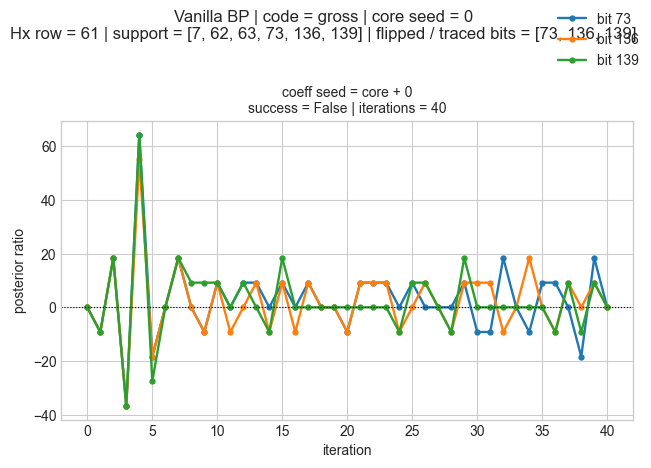

In [4]:
experiment_bp_seed0 = run_decoder_experiment(core_seed_zero, "bp", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_bp_seed0))
display(coefficient_table(experiment_bp_seed0))
plot_core_seed_experiment(experiment_bp_seed0);
plt.show()

,decoder,core_seed,hx_row,row_weight,support_bits,flipped_bits,syndrome_weight
0,Mem-BP / same coefficient,0,61,6,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]",9


,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,0,Mem-BP / same coefficient,0,0,73,0.15,False,40,"[7, 62, 63, 73, 136, 139]","[7, 62, 136, 139]","[7, 62, 136, 139]",[],4,0
1,0,Mem-BP / same coefficient,0,0,136,0.15,False,40,"[7, 62, 63, 73, 136, 139]","[7, 62, 136, 139]","[7, 62, 136, 139]",[],4,0
2,0,Mem-BP / same coefficient,0,0,139,0.15,False,40,"[7, 62, 63, 73, 136, 139]","[7, 62, 136, 139]","[7, 62, 136, 139]",[],4,0


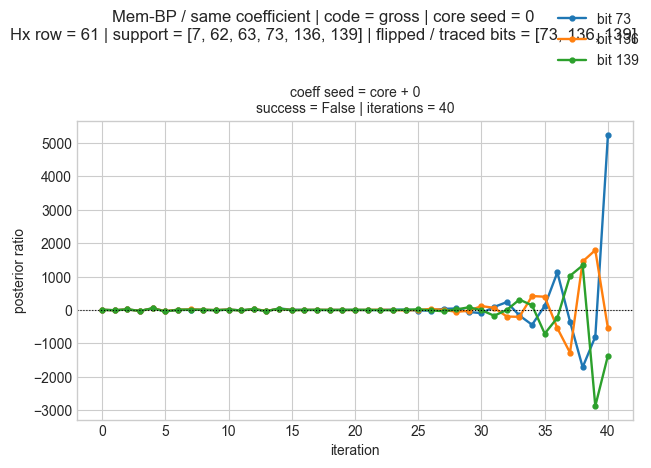

In [5]:
experiment_mem_same_seed0 = run_decoder_experiment(core_seed_zero, "mem_same", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_same_seed0))
display(coefficient_table(experiment_mem_same_seed0))
plot_core_seed_experiment(experiment_mem_same_seed0);
plt.show()

,decoder,core_seed,hx_row,row_weight,support_bits,flipped_bits,syndrome_weight
0,Mem-BP / random positive coefficients,0,61,6,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]",9


,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,0,Mem-BP / random positive coefficients,0,0,73,1.909181,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
1,0,Mem-BP / random positive coefficients,0,0,136,1.636242,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
2,0,Mem-BP / random positive coefficients,0,0,139,0.738809,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
3,0,Mem-BP / random positive coefficients,1,1,73,0.845434,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
4,0,Mem-BP / random positive coefficients,1,1,136,1.193975,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
5,0,Mem-BP / random positive coefficients,1,1,139,1.000713,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
6,0,Mem-BP / random positive coefficients,2,2,73,1.148933,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
7,0,Mem-BP / random positive coefficients,2,2,136,1.427278,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
8,0,Mem-BP / random positive coefficients,2,2,139,0.578556,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0


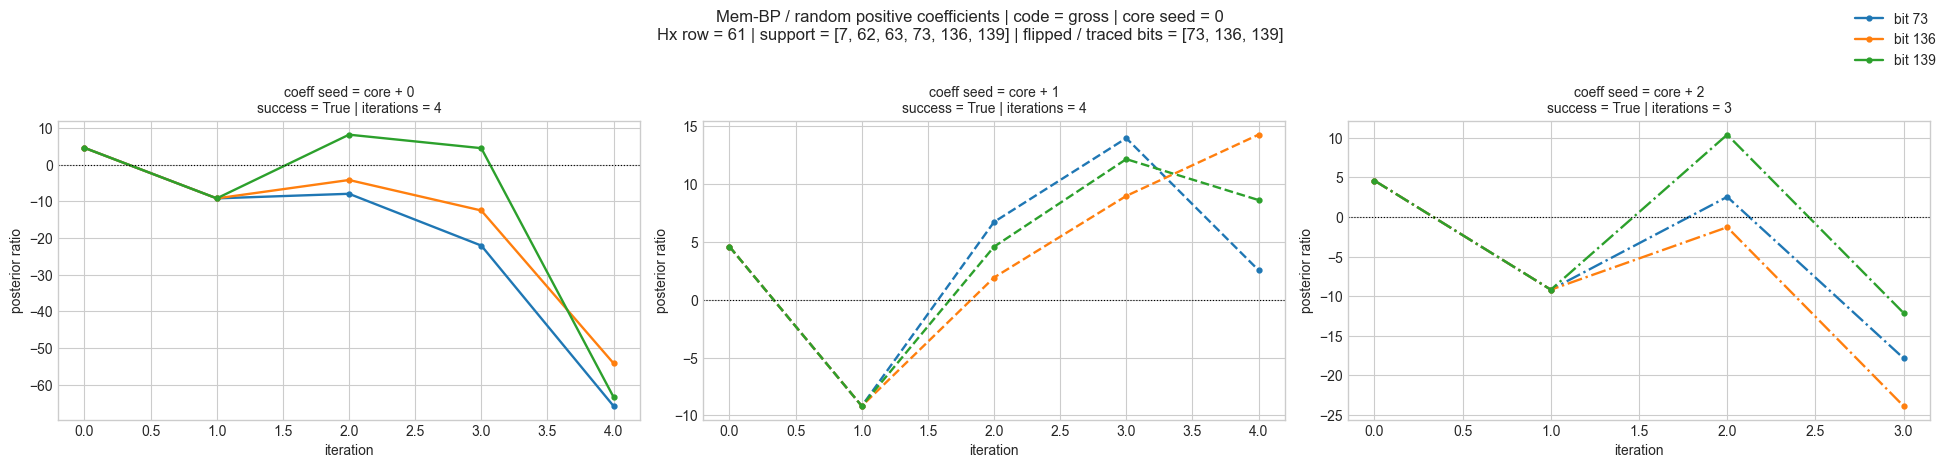

In [6]:
experiment_mem_positive_random_seed0 = run_decoder_experiment(core_seed_zero, "mem_positive_random", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_positive_random_seed0))
display(coefficient_table(experiment_mem_positive_random_seed0))
plot_core_seed_experiment(experiment_mem_positive_random_seed0);
plt.show()

,decoder,core_seed,hx_row,row_weight,support_bits,flipped_bits,syndrome_weight
0,Mem-BP / random signed coefficients,0,61,6,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]",9


,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,0,Mem-BP / random signed coefficients,0,0,73,1.809181,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
1,0,Mem-BP / random signed coefficients,0,0,136,1.536242,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
2,0,Mem-BP / random signed coefficients,0,0,139,0.638809,True,4,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
3,0,Mem-BP / random signed coefficients,1,1,73,0.745434,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
4,0,Mem-BP / random signed coefficients,1,1,136,1.093975,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
5,0,Mem-BP / random signed coefficients,1,1,139,0.900713,True,4,"[7, 62, 63, 73, 136, 139]","[7, 62, 63]","[7, 62, 63]",[],3,0
6,0,Mem-BP / random signed coefficients,2,2,73,1.048933,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
7,0,Mem-BP / random signed coefficients,2,2,136,1.327278,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0
8,0,Mem-BP / random signed coefficients,2,2,139,0.478556,True,3,"[7, 62, 63, 73, 136, 139]","[73, 136, 139]","[73, 136, 139]",[],3,0


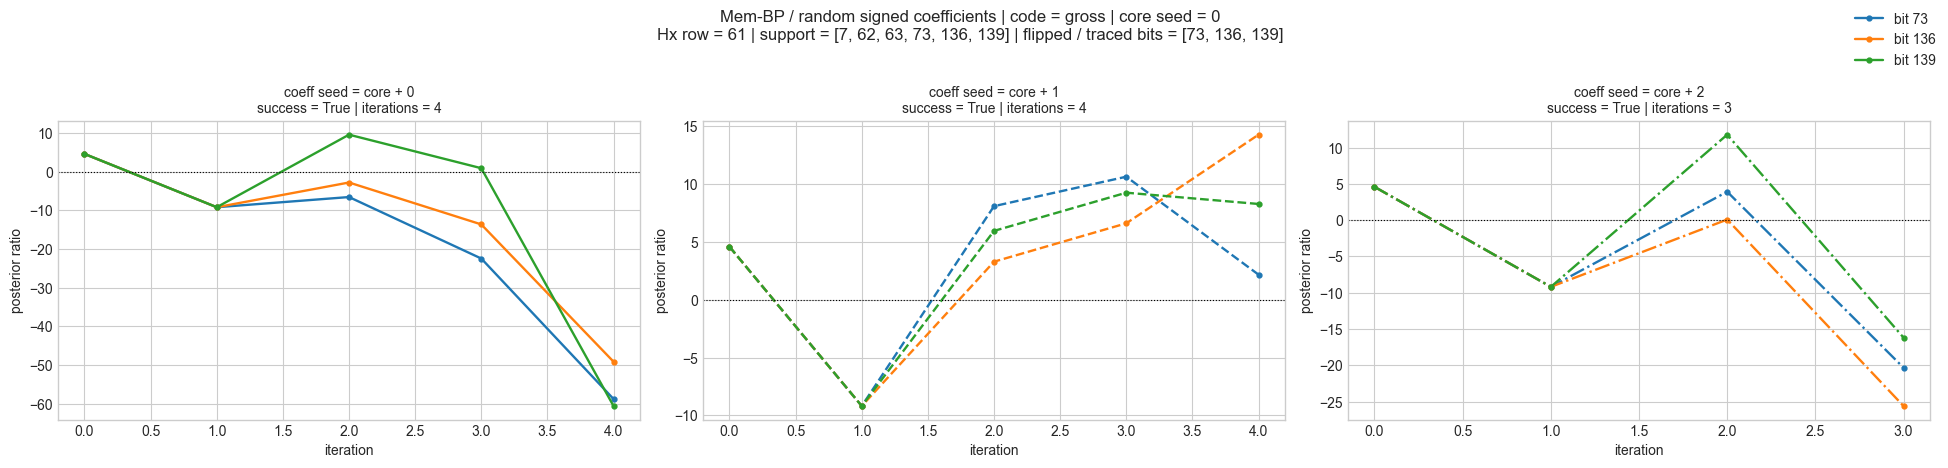

In [7]:
experiment_mem_signed_random_seed0 = run_decoder_experiment(core_seed_zero, "mem_signed_random", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_signed_random_seed0))
display(coefficient_table(experiment_mem_signed_random_seed0))
plot_core_seed_experiment(experiment_mem_signed_random_seed0);
plt.show()

## Core Seeds 1 To 10

Each of the next four cells runs one decoder family across `core_seed = 1..10` and creates a 2x5 plot grid.

,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,1,Vanilla BP,1,0,35,NaN,False,40,"[30, 35, 52, 103, 112, 118]","[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 112, 131, 139, 140]",[112],"[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 131, 139, 140]",14,13
1,1,Vanilla BP,1,0,52,NaN,False,40,"[30, 35, 52, 103, 112, 118]","[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 112, 131, 139, 140]",[112],"[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 131, 139, 140]",14,13
2,1,Vanilla BP,1,0,112,NaN,False,40,"[30, 35, 52, 103, 112, 118]","[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 112, 131, 139, 140]",[112],"[2, 9, 29, 40, 43, 61, 75, 88, 107, 111, 131, 139, 140]",14,13
3,2,Vanilla BP,2,0,6,NaN,False,40,"[6, 61, 62, 72, 135, 138]","[2, 5, 11, 20, 62, 72, 73, 112, 129, 130]","[62, 72]","[2, 5, 11, 20, 73, 112, 129, 130]",10,8
4,2,Vanilla BP,2,0,61,NaN,False,40,"[6, 61, 62, 72, 135, 138]","[2, 5, 11, 20, 62, 72, 73, 112, 129, 130]","[62, 72]","[2, 5, 11, 20, 73, 112, 129, 130]",10,8
5,2,Vanilla BP,2,0,72,NaN,False,40,"[6, 61, 62, 72, 135, 138]","[2, 5, 11, 20, 62, 72, 73, 112, 129, 130]","[62, 72]","[2, 5, 11, 20, 73, 112, 129, 130]",10,8
6,3,Vanilla BP,3,0,4,NaN,False,40,"[4, 54, 59, 127, 136, 142]","[1, 4, 49, 61, 64, 67, 96, 97, 101, 119, 135, 136]","[4, 136]","[1, 49, 61, 64, 67, 96, 97, 101, 119, 135]",12,10
7,3,Vanilla BP,3,0,54,NaN,False,40,"[4, 54, 59, 127, 136, 142]","[1, 4, 49, 61, 64, 67, 96, 97, 101, 119, 135, 136]","[4, 136]","[1, 49, 61, 64, 67, 96, 97, 101, 119, 135]",12,10
8,3,Vanilla BP,3,0,127,NaN,False,40,"[4, 54, 59, 127, 136, 142]","[1, 4, 49, 61, 64, 67, 96, 97, 101, 119, 135, 136]","[4, 136]","[1, 49, 61, 64, 67, 96, 97, 101, 119, 135]",12,10
9,4,Vanilla BP,4,0,70,NaN,False,40,"[48, 53, 70, 121, 130, 136]","[2, 7, 34, 42, 51, 52, 57, 74, 84, 86, 93, 96, 99, 131]",[],"[2, 7, 34, 42, 51, 52, 57, 74, 84, 86, 93, 96, 99, 131]",14,14


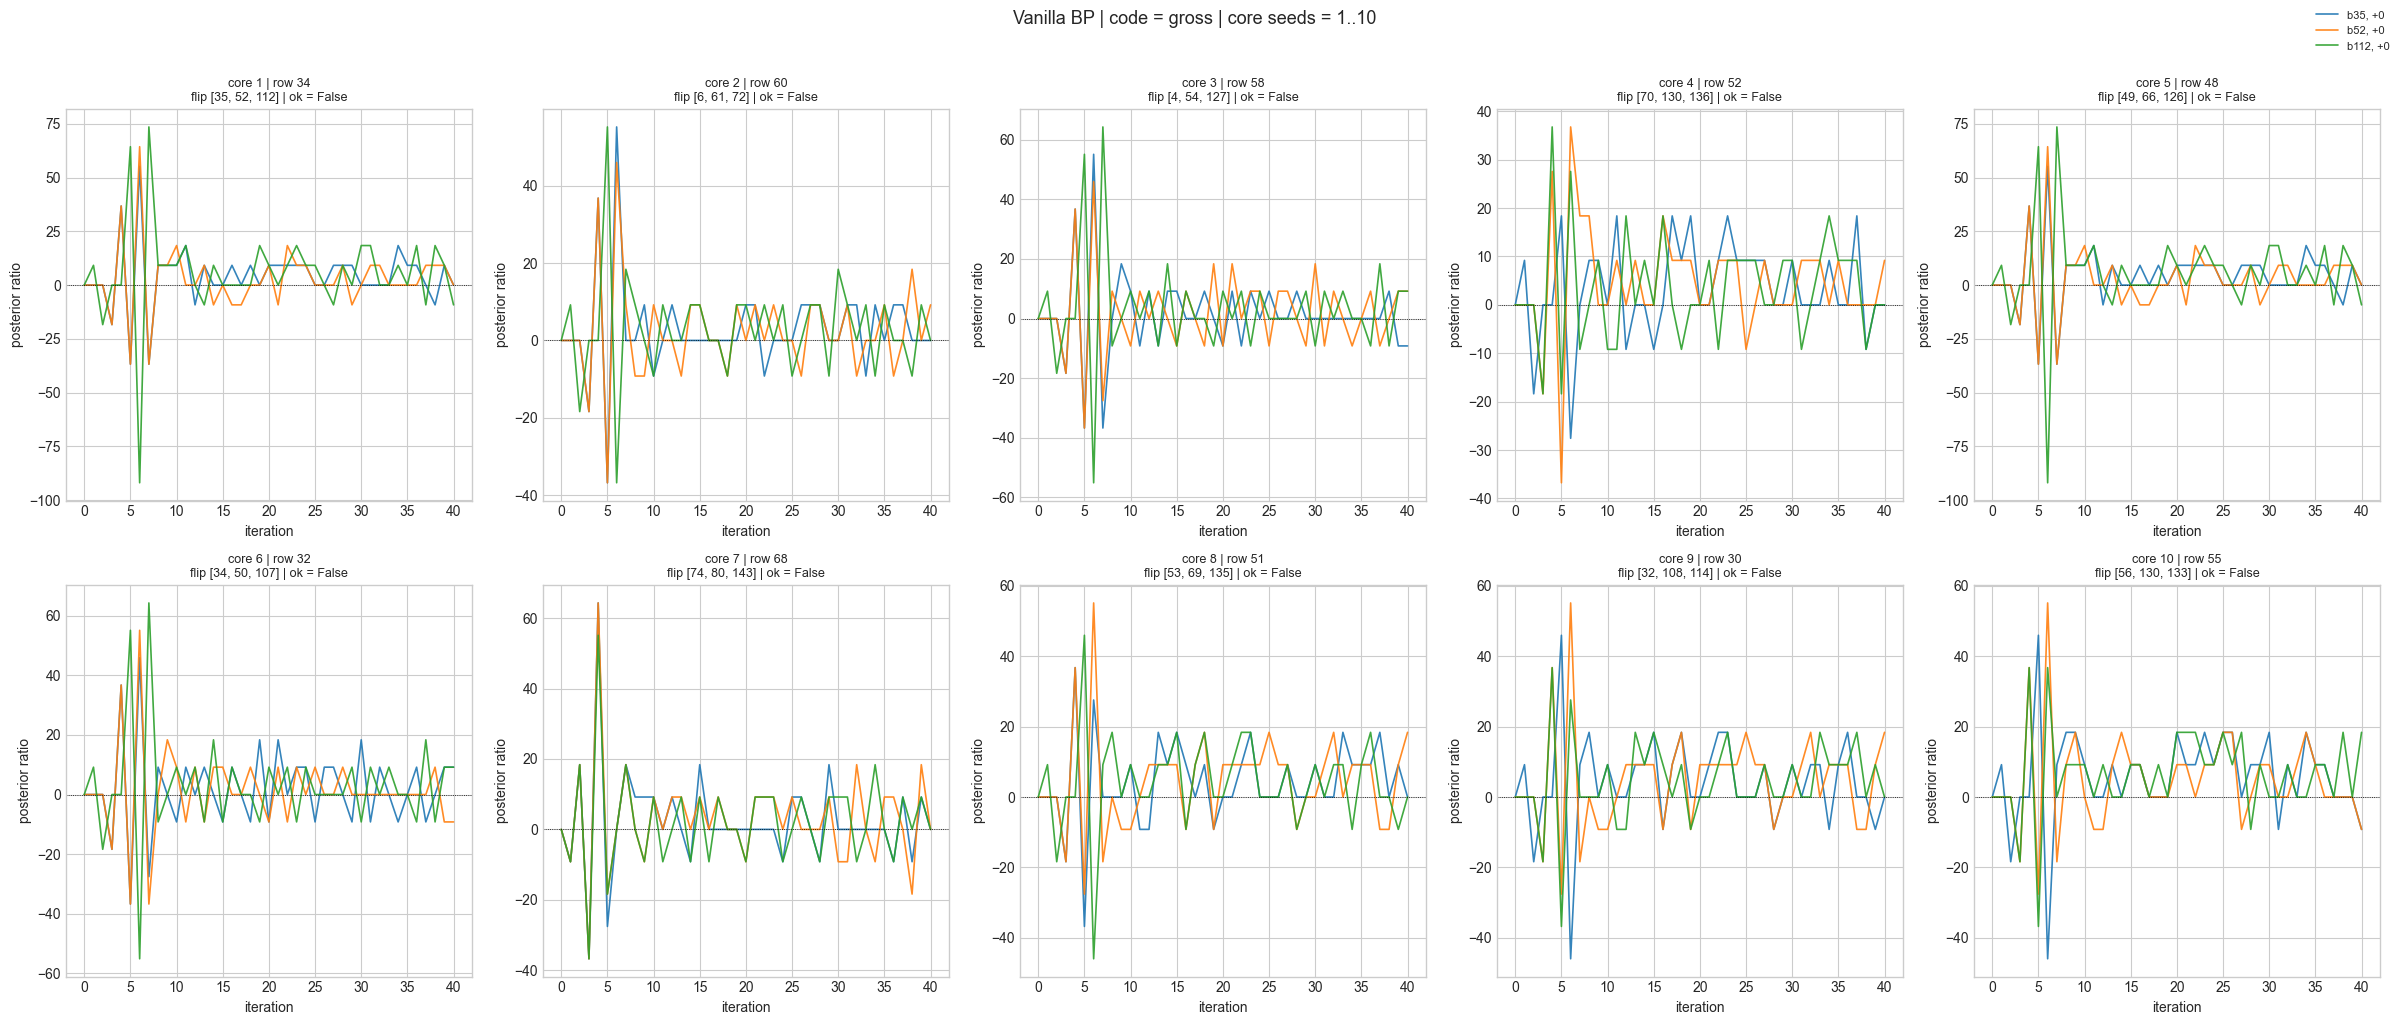

In [8]:
experiments_bp_grid, coeffs_bp_grid, fig_bp_grid = plot_seed_grid("bp", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_bp_grid)
plt.show()

,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,1,Mem-BP / same coefficient,1,0,35,0.15,True,18,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
1,1,Mem-BP / same coefficient,1,0,52,0.15,True,18,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
2,1,Mem-BP / same coefficient,1,0,112,0.15,True,18,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
3,2,Mem-BP / same coefficient,2,0,6,0.15,False,40,"[6, 61, 62, 72, 135, 138]","[61, 62, 72, 135]","[61, 62, 72, 135]",[],4,0
4,2,Mem-BP / same coefficient,2,0,61,0.15,False,40,"[6, 61, 62, 72, 135, 138]","[61, 62, 72, 135]","[61, 62, 72, 135]",[],4,0
5,2,Mem-BP / same coefficient,2,0,72,0.15,False,40,"[6, 61, 62, 72, 135, 138]","[61, 62, 72, 135]","[61, 62, 72, 135]",[],4,0
6,3,Mem-BP / same coefficient,3,0,4,0.15,False,40,"[4, 54, 59, 127, 136, 142]","[4, 59, 127, 136]","[4, 59, 127, 136]",[],4,0
7,3,Mem-BP / same coefficient,3,0,54,0.15,False,40,"[4, 54, 59, 127, 136, 142]","[4, 59, 127, 136]","[4, 59, 127, 136]",[],4,0
8,3,Mem-BP / same coefficient,3,0,127,0.15,False,40,"[4, 54, 59, 127, 136, 142]","[4, 59, 127, 136]","[4, 59, 127, 136]",[],4,0
9,4,Mem-BP / same coefficient,4,0,70,0.15,True,15,"[48, 53, 70, 121, 130, 136]","[48, 53, 121]","[48, 53, 121]",[],3,0


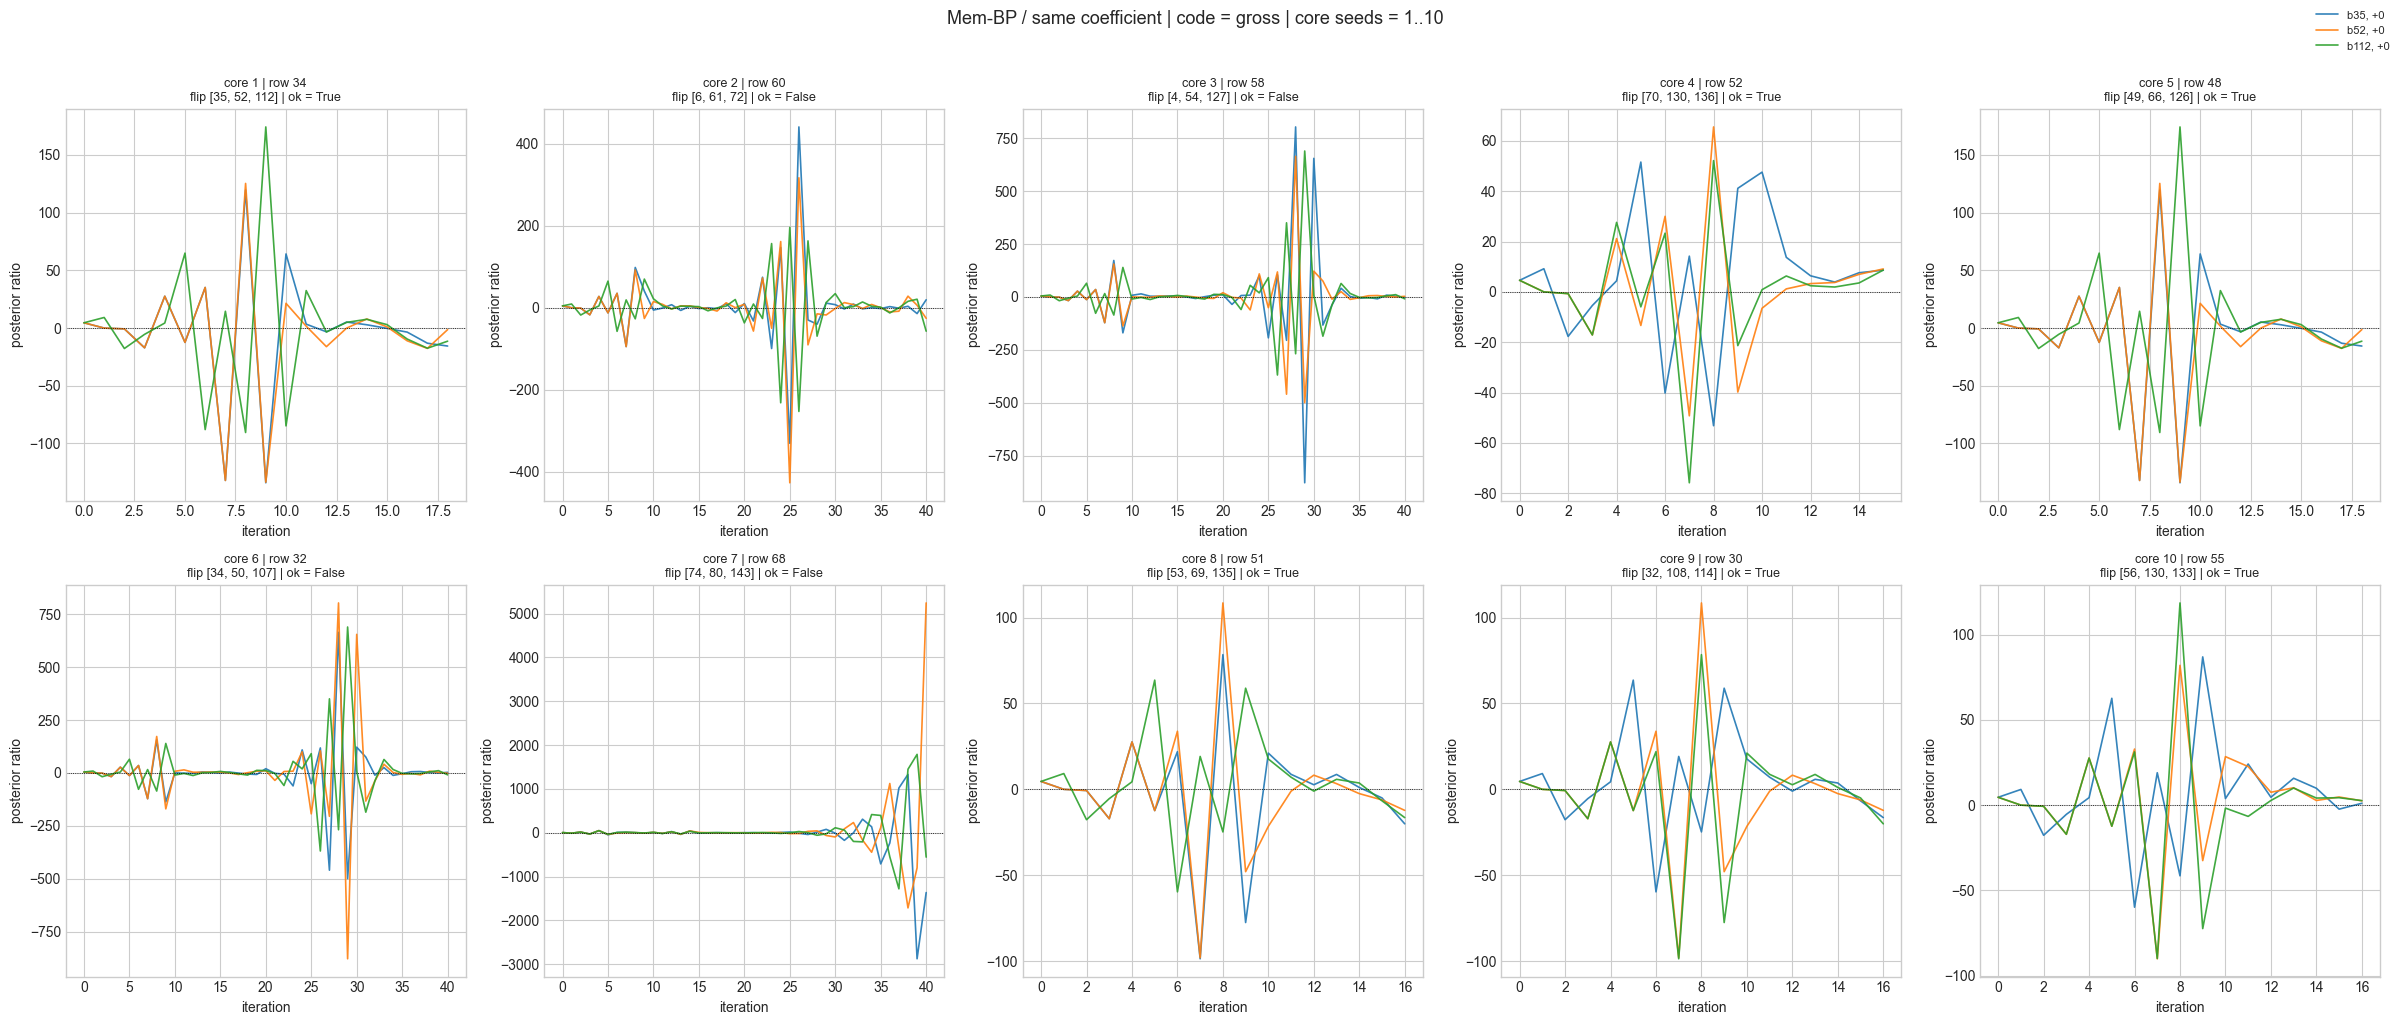

In [9]:
experiments_mem_same_grid, coeffs_mem_same_grid, fig_mem_same_grid = plot_seed_grid("mem_same", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_mem_same_grid)
plt.show()

,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,1,Mem-BP / random positive coefficients,1,0,35,1.834595,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
1,1,Mem-BP / random positive coefficients,1,0,52,0.383233,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
2,1,Mem-BP / random positive coefficients,1,0,112,0.515606,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
3,1,Mem-BP / random positive coefficients,2,1,35,0.813085,True,8,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
4,1,Mem-BP / random positive coefficients,2,1,52,1.795468,True,8,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
5,1,Mem-BP / random positive coefficients,2,1,112,0.913440,True,8,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
6,1,Mem-BP / random positive coefficients,3,2,35,1.260180,True,4,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
7,1,Mem-BP / random positive coefficients,3,2,52,1.396853,True,4,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
8,1,Mem-BP / random positive coefficients,3,2,112,0.697703,True,4,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
9,2,Mem-BP / random positive coefficients,2,0,6,0.375802,True,5,"[6, 61, 62, 72, 135, 138]","[62, 135, 138]","[62, 135, 138]",[],3,0


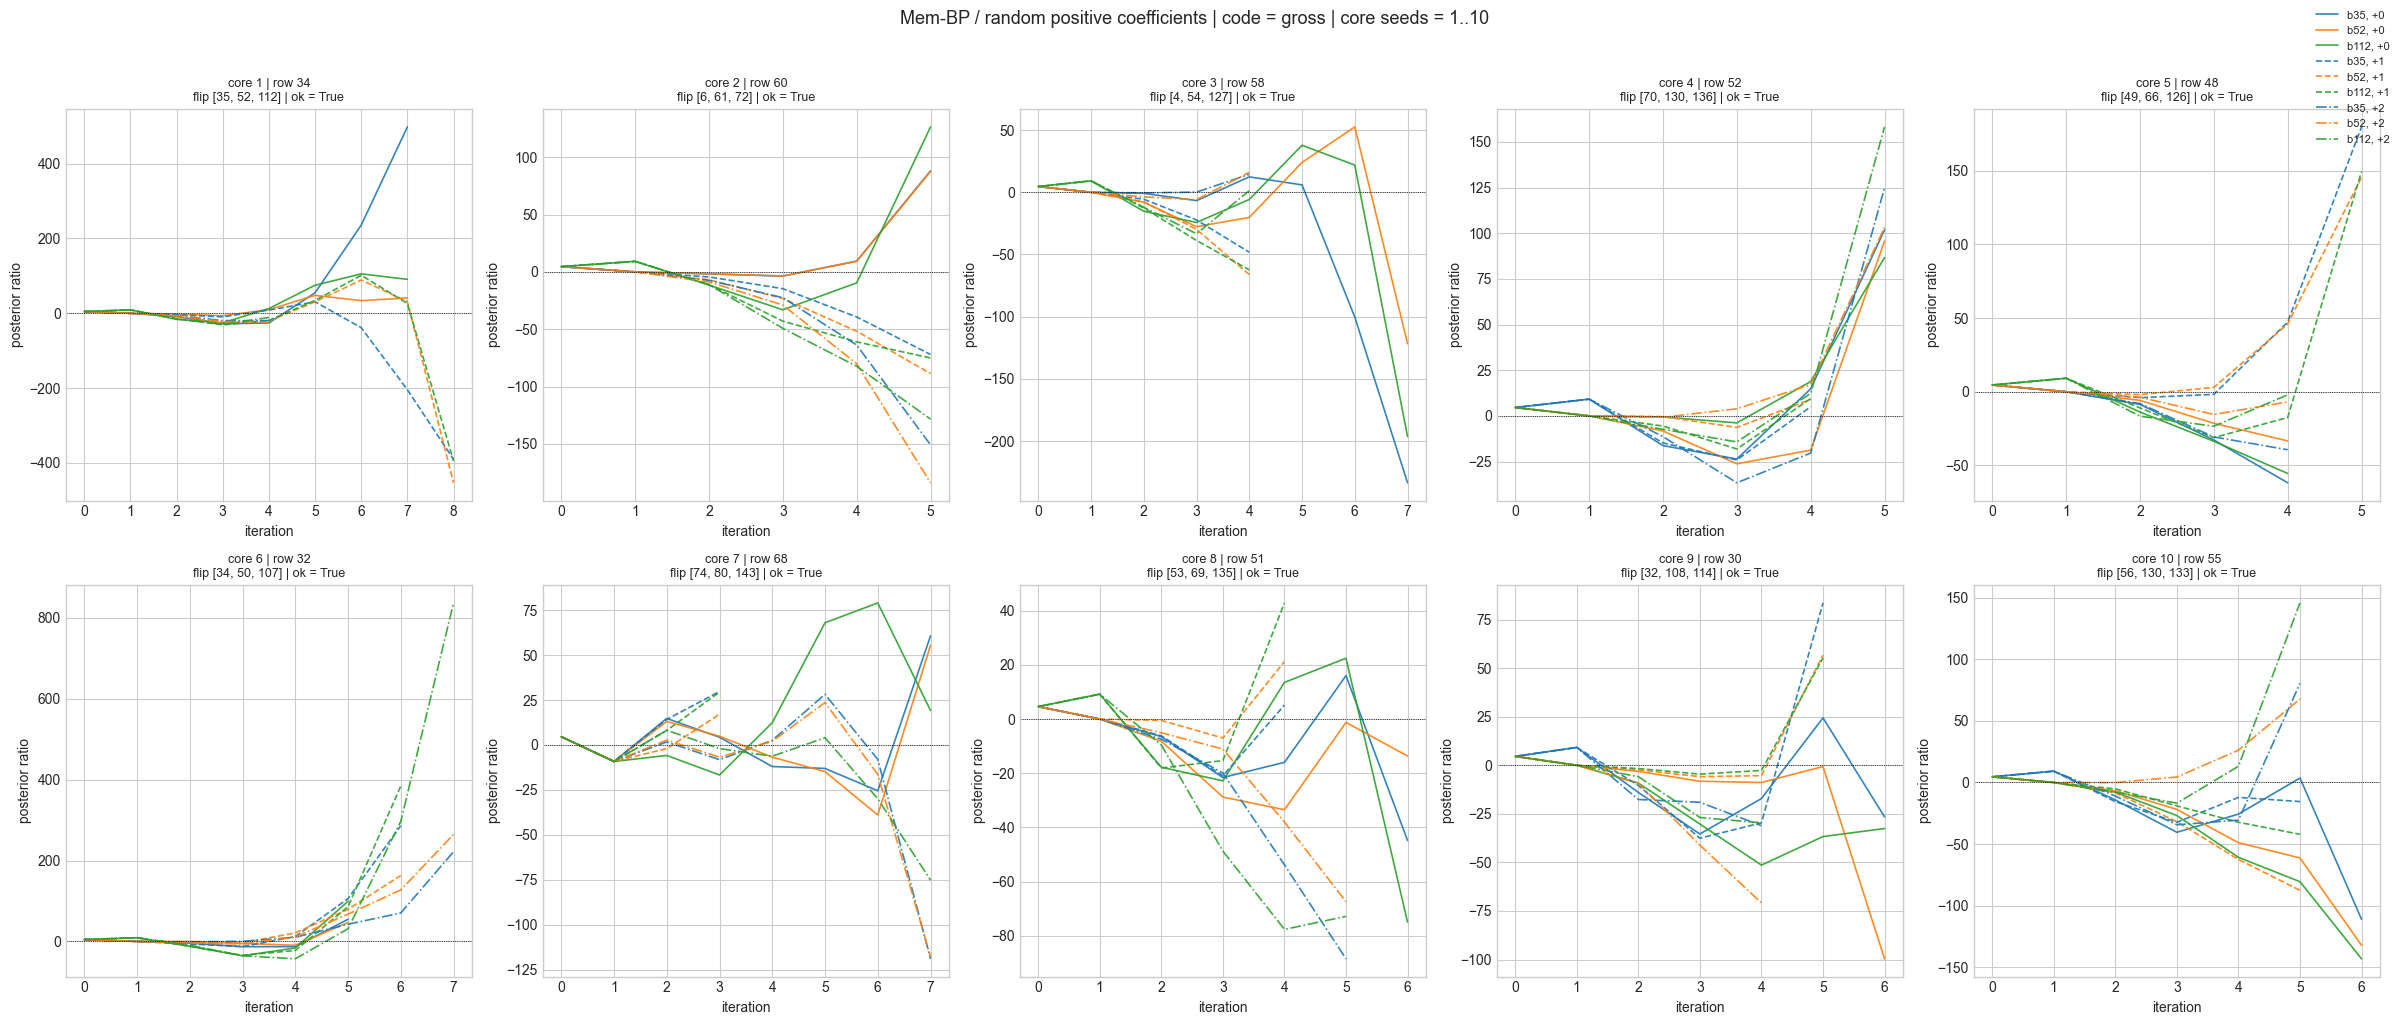

In [10]:
experiments_mem_positive_random_grid, coeffs_mem_positive_random_grid, fig_mem_positive_random_grid = plot_seed_grid("mem_positive_random", core_seed_grid, code_data, hz_check_matrix)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 200):
    display(coeffs_mem_positive_random_grid)
#display(coeffs_mem_positive_random_grid)
plt.show()

,core_seed,decoder,coeff_seed,coeff_seed_offset,bit,memory_coefficient,success,iterations,support_bits,final_estimated_error_bits,estimated_bits_in_support,estimated_bits_outside_support,n_estimated_bits,n_estimated_bits_outside_support
0,1,Mem-BP / random signed coefficients,1,0,35,1.734595,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
1,1,Mem-BP / random signed coefficients,1,0,52,0.283233,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
2,1,Mem-BP / random signed coefficients,1,0,112,0.415606,True,7,"[30, 35, 52, 103, 112, 118]","[30, 103, 118]","[30, 103, 118]",[],3,0
3,1,Mem-BP / random signed coefficients,2,1,35,0.713085,True,8,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
4,1,Mem-BP / random signed coefficients,2,1,52,1.695468,True,8,"[30, 35, 52, 103, 112, 118]","[35, 52, 112]","[35, 52, 112]",[],3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,10,Mem-BP / random signed coefficients,11,1,130,1.725278,True,5,"[1, 56, 57, 130, 133, 139]","[56, 130, 133]","[56, 130, 133]",[],3,0
86,10,Mem-BP / random signed coefficients,11,1,133,1.023004,True,5,"[1, 56, 57, 130, 133, 139]","[56, 130, 133]","[56, 130, 133]",[],3,0
87,10,Mem-BP / random signed coefficients,12,2,56,1.501556,True,5,"[1, 56, 57, 130, 133, 139]","[1, 57, 139]","[1, 57, 139]",[],3,0
88,10,Mem-BP / random signed coefficients,12,2,130,-0.086836,True,5,"[1, 56, 57, 130, 133, 139]","[1, 57, 139]","[1, 57, 139]",[],3,0


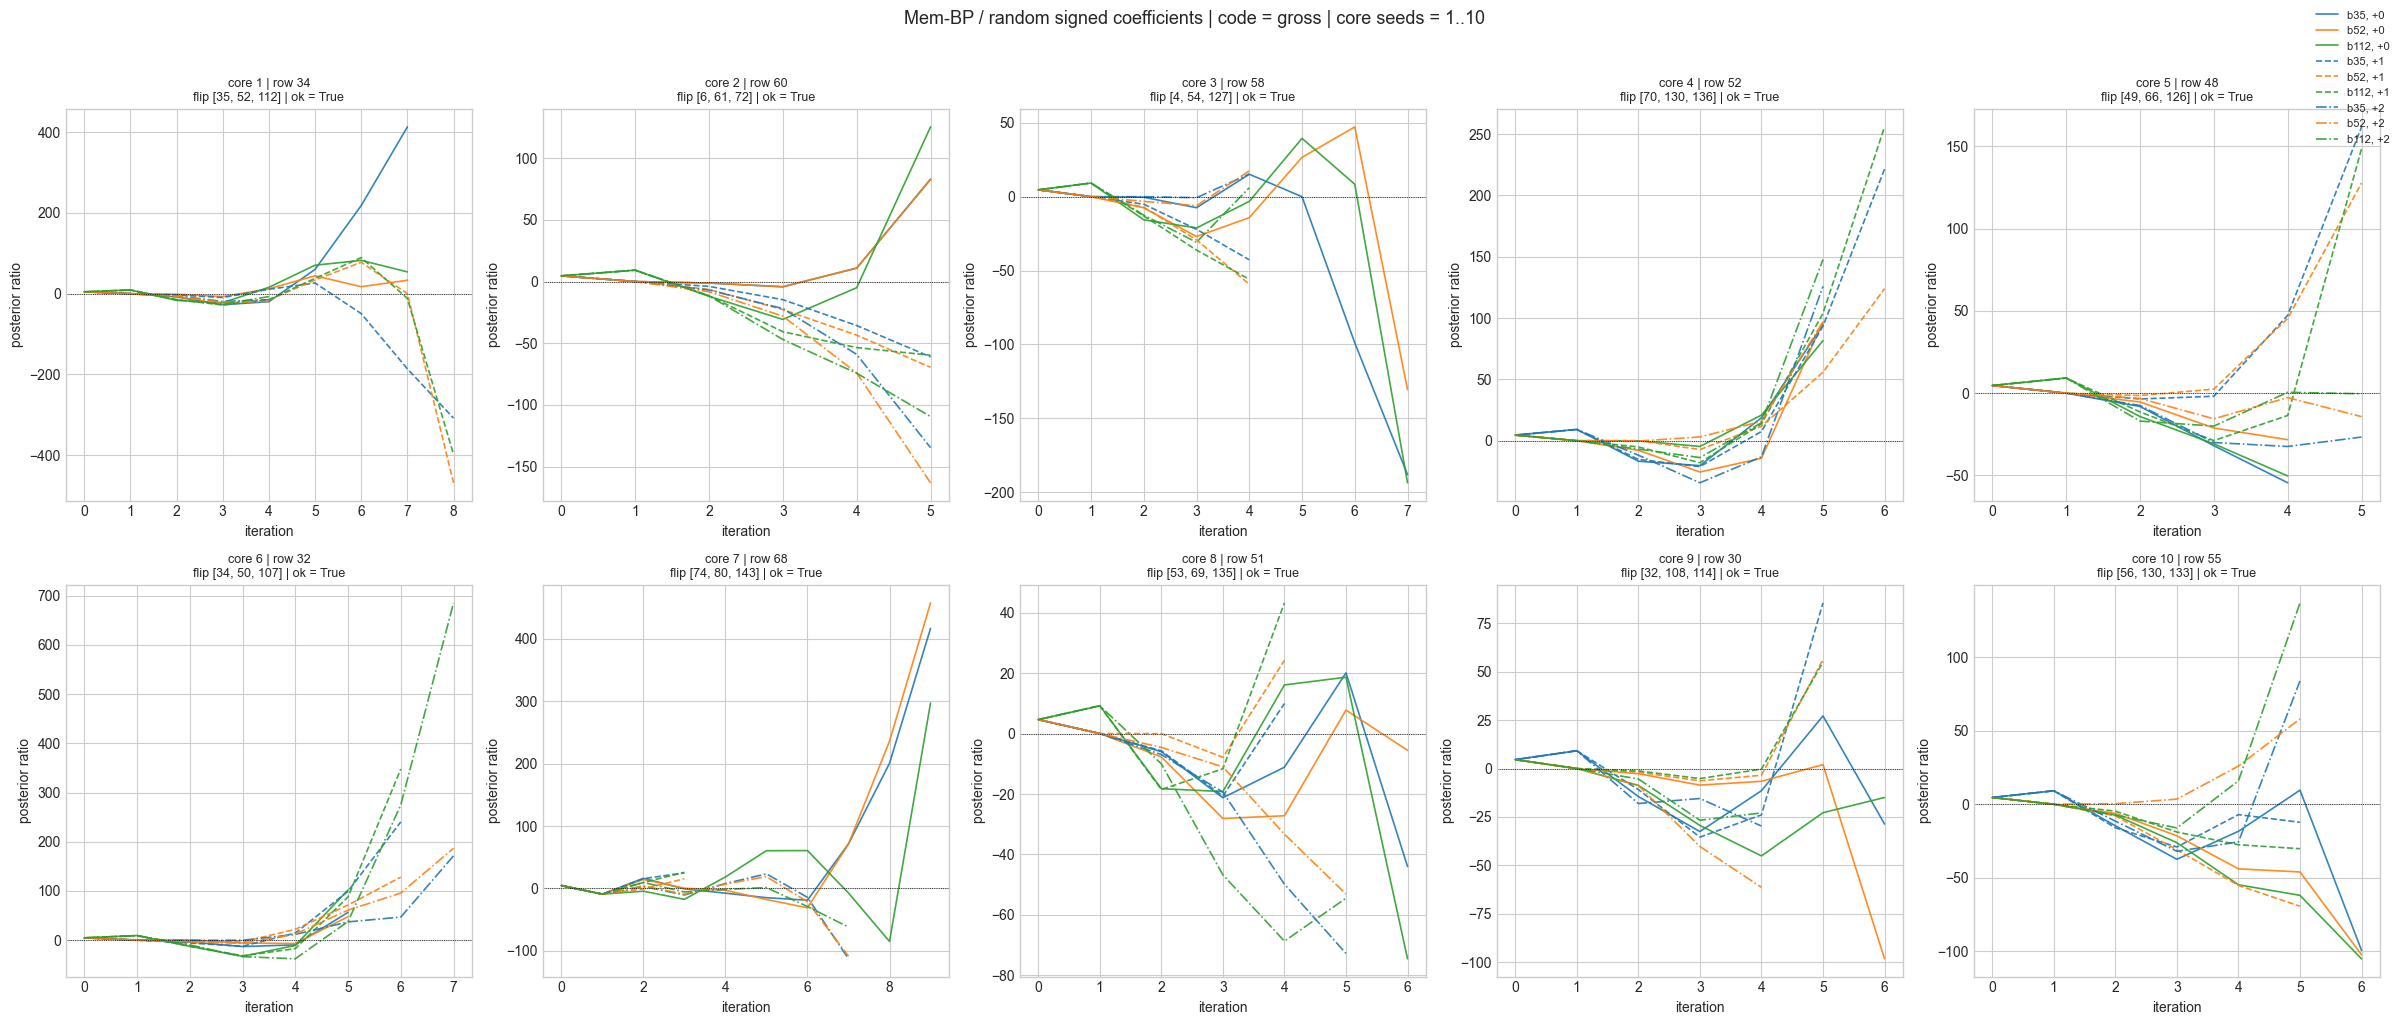

In [11]:
experiments_mem_signed_random_grid, coeffs_mem_signed_random_grid, fig_mem_signed_random_grid = plot_seed_grid("mem_signed_random", core_seed_grid, code_data, hz_check_matrix)
#with pd.option_context("display.max_rows", None, "display.max_colwidth", 200):
#    display(coeffs_mem_signed_random_grid)
display(coeffs_mem_signed_random_grid)
plt.show()